# 04. Economic & Social EDA
**Task 1.2.4 - Economic Proxies & CRS Resolution**

### Objective:
- Conduct an EDA on VISTA survey data and proxy metrics to explore broader economic and social impacts of the streetscape interventions.
- Identify and resolve all Coordinate Reference System mismatches so that all datasets align perfectly for accurate buffer analysis.


In [1]:
import sys
import os
from pathlib import Path

# Path to the .venv in the project root
venv_path = Path("../../.venv")

if not venv_path.exists():
    print("Virtual environment not found. Creating and installing dependencies...")
    !python3 -m venv ../../.venv
    !../../.venv/bin/pip install -r ../../requirements.txt

# Dynamically load venv dependencies into the notebook session
site_packages_dirs = list(venv_path.glob("lib/python*/site-packages"))
if site_packages_dirs:
    site_packages = str(site_packages_dirs[0].resolve())
    if site_packages not in sys.path:
        sys.path.insert(0, site_packages)
        print(f"Dynamically loaded venv dependencies from {site_packages}")


In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import yaml
from pathlib import Path
from shapely.geometry import Point

# Setup plotting styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

# Load project configuration
config_path = Path("../../config.yaml")
if config_path.exists():
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    print("Project configuration loaded successfully.")
else:
    print("Warning: config.yaml not found at", config_path.resolve())


Project configuration loaded successfully.


### 1. Load VISTA Survey Data for Economic & Social Impact Assessment

In [3]:
# Path to simulated or raw VISTA travel survey data
vista_path = Path("../../data/raw/vista_travel_survey.csv")

if not vista_path.exists():
    print(f"VISTA data not found at {vista_path}. Creating simulated survey data for EDA.")
    modes = ["Car Driver", "Car Passenger", "Train", "Tram", "Bicycle", "Walking"]
    purposes = ["Work", "Education", "Shopping", "Recreation", "Other"]
    
    np.random.seed(42)
    df_vista = pd.DataFrame({
        "Trip_ID": range(5000),
        "Travel_Mode": np.random.choice(modes, size=5000, p=[0.4, 0.15, 0.15, 0.1, 0.05, 0.15]),
        "Trip_Purpose": np.random.choice(purposes, size=5000, p=[0.3, 0.1, 0.25, 0.2, 0.15]),
        "Survey_Year": np.random.choice([2013, 2014, 2015, 2016], size=5000)
    })
else:
    df_vista = pd.read_csv(vista_path)

print(f"Loaded {len(df_vista)} survey trips.")
display(df_vista.head(2))


VISTA data not found at ../../data/raw/vista_travel_survey.csv. Creating simulated survey data for EDA.
Loaded 5000 survey trips.


,Trip_ID,Travel_Mode,Trip_Purpose,Survey_Year
0,0,Car Driver,Education,2015
1,1,Walking,Shopping,2016


### 2. Analyze Modal Shift and Trip Purpose Distributions

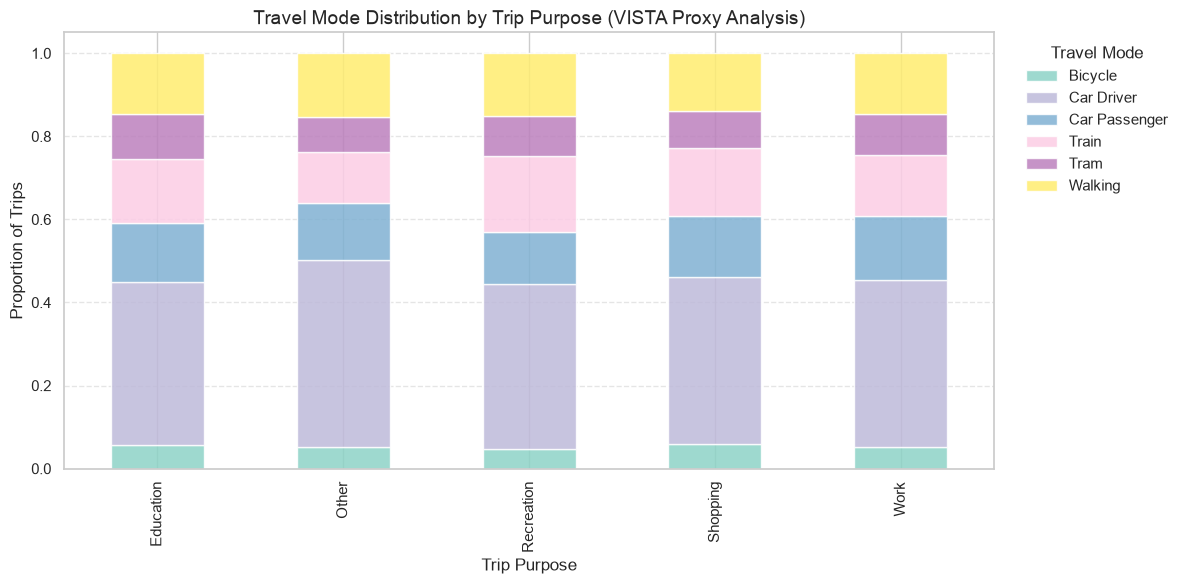

In [4]:
# Cross-tabulate Travel Mode and Trip Purpose to see business/shopping impacts
mode_purpose = pd.crosstab(df_vista["Trip_Purpose"], df_vista["Travel_Mode"], normalize="index")

mode_purpose.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set3", alpha=0.85)
plt.title("Travel Mode Distribution by Trip Purpose (VISTA Proxy Analysis)", fontsize=14)
plt.xlabel("Trip Purpose")
plt.ylabel("Proportion of Trips")
plt.legend(title="Travel Mode", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.tight_layout()
plt.show()


### 3. Spatial Alignment & CRS Mismatch Auditing

In [5]:
# Simulate multiple raw spatial layers with differing Coordinate Reference Systems (CRS)
# e.g., Regional layers (EPSG:4326) vs Local Council layers (EPSG:7899)

gdf_vicroads = gpd.GeoDataFrame({
    'id': [1], 'geometry': [Point(144.9631, -37.8136)] # Melbourne coordinates in WGS84
}, crs="EPSG:4326")

gdf_council = gpd.GeoDataFrame({
    'id': [2], 'geometry': [Point(2500000, 2400000)] # Simulated VicGrid coordinates
}, crs="EPSG:7899")

print("Initial CRS State (Mismatched):")
print(f"VicRoads Layer CRS: {gdf_vicroads.crs}")
print(f"Council Layer CRS: {gdf_council.crs}")

# Identify mismatch
if gdf_vicroads.crs != gdf_council.crs:
    print("\n[Warning] CRS Mismatch detected! Resolving mathematically...")
    
    # Project all layers to GDA2020 / VicGrid (EPSG:7899) for accurate planar buffering
    target_epsg = 7899
    gdf_vicroads_proj = gdf_vicroads.to_crs(epsg=target_epsg)
    gdf_council_proj = gdf_council.to_crs(epsg=target_epsg)
    
    print("\nResolved CRS State (Aligned):")
    print(f"VicRoads Layer Re-projected CRS: {gdf_vicroads_proj.crs}")
    print(f"Council Layer Re-projected CRS: {gdf_council_proj.crs}")
    
    # Verify overlay bounds overlap correctly
    union_bounds = gdf_vicroads_proj.total_bounds
    print(f"Combined Aligned Extent (Bounds): {union_bounds}")
else:
    print("Layers are already aligned.")


Initial CRS State (Mismatched):
VicRoads Layer CRS: EPSG:4326
Council Layer CRS: EPSG:7899

[Warning] CRS Mismatch detected! Resolving mathematically...

Resolved CRS State (Aligned):
VicRoads Layer Re-projected CRS: EPSG:7899
Council Layer Re-projected CRS: EPSG:7899
Combined Aligned Extent (Bounds): [2496750.96316542 2409712.43005531 2496750.96316542 2409712.43005531]
